<a href="https://colab.research.google.com/github/sathana495/ML-project/blob/main/predicting_house_price1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### ***predict house price*** ###

##step 1 : upload and cleaning data ##

In [ ]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/dataset/paris_housing_prices_dataset.csv')
df.head(5)



,Property_ID,Arrondissement,Property_Type,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km,Price_EUR
0,P10000,4,Apartment,117,4,7,1870,Renovated,2.76,2270802.89
1,P10001,8,Studio,89,3,3,1953,Good,10.77,1637076.12
2,P10002,4,Apartment,164,5,5,1979,Needs Renovation,3.14,3220782.59
3,P10003,2,Apartment,35,1,5,1938,New,4.72,407781.74
4,P10004,7,Studio,73,2,2,1957,New,7.96,624879.12


In [ ]:
df.tail(5)

,Property_ID,Arrondissement,Property_Type,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km,Price_EUR
1195,P11195,14,Studio,173,5,5,2010,Renovated,2.42,2328490.48
1196,P11196,16,Penthouse,192,4,1,1965,Good,6.56,2794554.47
1197,P11197,6,Loft,123,2,7,1961,New,13.18,2247682.75
1198,P11198,8,Studio,151,2,1,1926,Good,14.43,1236847.52
1199,P11199,7,Apartment,29,4,4,2018,Good,11.57,265630.92


In [ ]:
df.describe()

,Arrondissement,Size_sqm,Rooms,Floor,Year_Built,Distance_to_Center_km,Price_EUR
count,1200.00000,1200.000000,1200.000000,1200.000000,1200.0000,1200.000000,1.200000e+03
mean,10.81750,108.125833,3.000000,4.390833,1935.6725,7.755375,1.521459e+06
std,5.65811,54.176125,1.414214,2.899728,49.8934,4.179961,8.737896e+05
min,1.00000,15.000000,1.000000,0.000000,1850.0000,0.510000,1.205258e+05
25%,6.00000,62.000000,2.000000,2.000000,1894.0000,4.137500,7.847546e+05
50%,11.00000,108.000000,3.000000,4.000000,1935.0000,7.705000,1.430473e+06
75%,16.00000,157.000000,4.000000,7.000000,1977.0000,11.347500,2.125367e+06
max,20.00000,199.000000,5.000000,9.000000,2023.0000,14.990000,3.950832e+06


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Property_ID            1200 non-null   object 
 1   Arrondissement         1200 non-null   int64  
 2   Property_Type          1200 non-null   object 
 3   Size_sqm               1200 non-null   int64  
 4   Rooms                  1200 non-null   int64  
 5   Floor                  1200 non-null   int64  
 6   Year_Built             1200 non-null   int64  
 7   Condition              1200 non-null   object 
 8   Distance_to_Center_km  1200 non-null   float64
 9   Price_EUR              1200 non-null   float64
dtypes: float64(2), int64(5), object(3)
memory usage: 93.9+ KB


In [ ]:
df.isna().sum()

,0
Property_ID,0
Arrondissement,0
Property_Type,0
Size_sqm,0
Rooms,0
Floor,0
Year_Built,0
Condition,0
Distance_to_Center_km,0
Price_EUR,0


##step 2: preprocessing the dataset ##

In [ ]:
df['Property_Type'].nunique()

4

In [ ]:
df['Property_Type']=df['Property_Type'].replace({'Studio':0,'Penthouse':1,'Loft':2,'Apartment':3})


/tmp/ipykernel_698/2048080266.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Property_Type']=df['Property_Type'].replace({'Studio':0,'Penthouse':1,'Loft':2,'Apartment':3})


In [ ]:
df.head()

,Property_ID,Arrondissement,Property_Type,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km,Price_EUR
0,P10000,4,3,117,4,7,1870,Renovated,2.76,2270802.89
1,P10001,8,0,89,3,3,1953,Good,10.77,1637076.12
2,P10002,4,3,164,5,5,1979,Needs Renovation,3.14,3220782.59
3,P10003,2,3,35,1,5,1938,New,4.72,407781.74
4,P10004,7,0,73,2,2,1957,New,7.96,624879.12


In [ ]:
df['Condition'].nunique()

4

In [ ]:
df['Condition'] = df['Condition'].replace({'Renovated':0,'Good':1,'Needs Renovation':2,'New':3})

/tmp/ipykernel_698/684485253.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Condition'] = df['Condition'].replace({'Renovated':0,'Good':1,'Needs Renovation':2,'New':3})


In [ ]:
df.head()

,Property_ID,Arrondissement,Property_Type,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km,Price_EUR
0,P10000,4,3,117,4,7,1870,0,2.76,2270802.89
1,P10001,8,0,89,3,3,1953,1,10.77,1637076.12
2,P10002,4,3,164,5,5,1979,2,3.14,3220782.59
3,P10003,2,3,35,1,5,1938,3,4.72,407781.74
4,P10004,7,0,73,2,2,1957,3,7.96,624879.12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Property_ID            1200 non-null   object 
 1   Arrondissement         1200 non-null   int64  
 2   Property_Type          1200 non-null   int64  
 3   Size_sqm               1200 non-null   int64  
 4   Rooms                  1200 non-null   int64  
 5   Floor                  1200 non-null   int64  
 6   Year_Built             1200 non-null   int64  
 7   Condition              1200 non-null   int64  
 8   Distance_to_Center_km  1200 non-null   float64
 9   Price_EUR              1200 non-null   float64
dtypes: float64(2), int64(7), object(1)
memory usage: 93.9+ KB


In [ ]:
df['Property_ID'] = df['Property_ID'].str[1:].astype(int) - 9999

In [ ]:
df.head()

,Property_ID,Arrondissement,Property_Type,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km,Price_EUR
0,1,4,3,117,4,7,1870,0,2.76,2270802.89
1,2,8,0,89,3,3,1953,1,10.77,1637076.12
2,3,4,3,164,5,5,1979,2,3.14,3220782.59
3,4,2,3,35,1,5,1938,3,4.72,407781.74
4,5,7,0,73,2,2,1957,3,7.96,624879.12


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
# Ensure df is in the correct state with 'Price_EUR' column
# Reload the original dataset
df = pd.read_csv('/content/drive/MyDrive/dataset/paris_housing_prices_dataset.csv')

# Re-apply Property_Type encoding
df['Property_Type']=df['Property_Type'].replace({'Studio':0,'Penthouse':1,'Loft':2,'Apartment':3})

# Re-apply Condition encoding
df['Condition'] = df['Condition'].replace({'Renovated':0,'Good':1,'Needs Renovation':2,'New':3})

# Re-apply Property_ID conversion
df['Property_ID'] = df['Property_ID'].str[1:].astype(int) - 9999

# Now, apply StandardScaler to 'Price_EUR'
df['Price_EUR_scaled'] = scaler.fit_transform(df[['Price_EUR']])

/tmp/ipykernel_6299/268177228.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Property_Type']=df['Property_Type'].replace({'Studio':0,'Penthouse':1,'Loft':2,'Apartment':3})
/tmp/ipykernel_6299/268177228.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Condition'] = df['Condition'].replace({'Renovated':0,'Good':1,'Needs Renovation':2,'New':3})


In [ ]:
df.head()

,Property_ID,Arrondissement,Property_Type,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km,Price_EUR,Price_EUR_scaled
0,1,4,3,117,4,7,1870,0,2.76,2270802.89,0.857937
1,2,8,0,89,3,3,1953,1,10.77,1637076.12,0.132372
2,3,4,3,164,5,5,1979,2,3.14,3220782.59,1.945585
3,4,2,3,35,1,5,1938,3,4.72,407781.74,-1.275068
4,5,7,0,73,2,2,1957,3,7.96,624879.12,-1.026510


In [ ]:
df = df.drop('Price_EUR', axis=1, errors='ignore')

In [ ]:
df.head()

,Property_ID,Arrondissement,Property_Type,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km,Price_EUR_scaled
0,1,4,3,117,4,7,1870,0,2.76,0.857937
1,2,8,0,89,3,3,1953,1,10.77,0.132372
2,3,4,3,164,5,5,1979,2,3.14,1.945585
3,4,2,3,35,1,5,1938,3,4.72,-1.275068
4,5,7,0,73,2,2,1957,3,7.96,-1.026510


## step3:  Data visualization for understandin ##

In [ ]:
core=df.corr()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

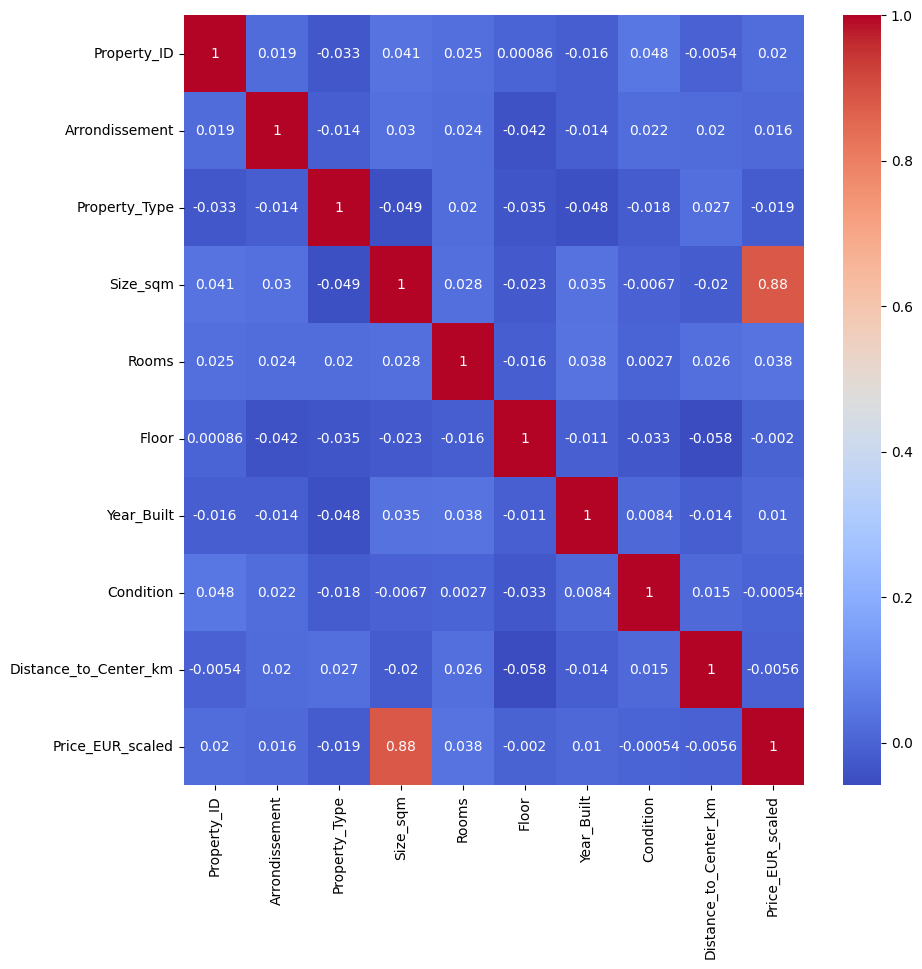

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(core,annot=True,cmap='coolwarm')
plt.show()

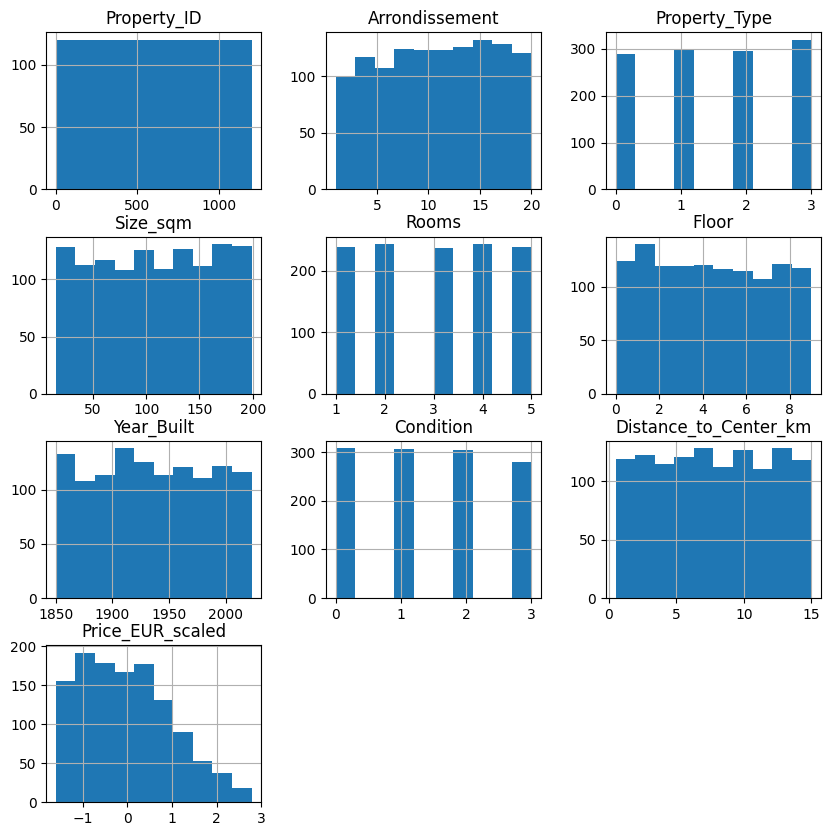

In [ ]:
df.hist(figsize=(10,10),bins=10)
plt.show()

In [ ]:
X = df.drop('Price_EUR_scaled',axis=1)
Y = df['Price_EUR_scaled']

In [ ]:
X

,Property_ID,Arrondissement,Property_Type,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km
0,1,4,3,117,4,7,1870,0,2.76
1,2,8,0,89,3,3,1953,1,10.77
2,3,4,3,164,5,5,1979,2,3.14
3,4,2,3,35,1,5,1938,3,4.72
4,5,7,0,73,2,2,1957,3,7.96
...,...,...,...,...,...,...,...,...,...
1195,1196,14,0,173,5,5,2010,0,2.42
1196,1197,16,1,192,4,1,1965,1,6.56
1197,1198,6,2,123,2,7,1961,3,13.18
1198,1199,8,0,151,2,1,1926,1,14.43


In [ ]:
Y

,Price_EUR_scaled
0,0.857937
1,0.132372
2,1.945585
3,-1.275068
4,-1.026510
...,...
1195,0.923985
1196,1.457589
1197,0.831466
1198,-0.325856


## step4 : Using LinearRegression model ##

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr = LinearRegression()

In [ ]:
lr.fit(X_train,Y_train)

LinearRegression()

In [ ]:
Y_predict = lr.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [ ]:
lr_accuracy = r2_score(Y_test,Y_predict)*100

In [ ]:
lr_accuracy

78.20839330152683

## step5 : Random Forest Regressor model ##

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, Y_train)
Y_predict_rf = rf.predict(X_test)
rf_accuracy = r2_score(Y_test, Y_predict_rf) * 100
print(f"Random Forest Regressor R-squared accuracy: {rf_accuracy:.2f}%")

Random Forest Regressor R-squared accuracy: 76.40%
